In [2]:
from pathlib import Path 
import pandas as pd 

filepath = Path("../data/raw") / "Medicare_IP_Hospitals_by_Provider_and_Service_2024.csv"

df = pd.read_csv(
    filepath,
    dtype = {
        'Rndrng_Prvdr_CCN': str,
        'Rndrng_Prvdr_State_FIPS': str,
        'Rndrng_Prvdr_Zip5': str,
        'DRG_Cd': str
    })

df.shape

(145879, 15)

In [3]:
df.columns = df.columns.str.lower()

df.columns

Index(['rndrng_prvdr_ccn', 'rndrng_prvdr_org_name', 'rndrng_prvdr_city',
       'rndrng_prvdr_st', 'rndrng_prvdr_state_fips', 'rndrng_prvdr_zip5',
       'rndrng_prvdr_state_abrvtn', 'rndrng_prvdr_ruca',
       'rndrng_prvdr_ruca_desc', 'drg_cd', 'drg_desc', 'tot_dschrgs',
       'avg_submtd_cvrd_chrg', 'avg_tot_pymt_amt', 'avg_mdcr_pymt_amt'],
      dtype='object')

In [4]:
df.head()

,rndrng_prvdr_ccn,rndrng_prvdr_org_name,rndrng_prvdr_city,rndrng_prvdr_st,rndrng_prvdr_state_fips,rndrng_prvdr_zip5,rndrng_prvdr_state_abrvtn,rndrng_prvdr_ruca,rndrng_prvdr_ruca_desc,drg_cd,drg_desc,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt
0,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,003,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818
1,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,023,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217
2,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,024,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692
3,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,025,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636
4,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,038,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222


In [5]:
df.isna().sum()

rndrng_prvdr_ccn             0
rndrng_prvdr_org_name        0
rndrng_prvdr_city            0
rndrng_prvdr_st              0
rndrng_prvdr_state_fips      0
rndrng_prvdr_zip5            0
rndrng_prvdr_state_abrvtn    0
rndrng_prvdr_ruca            0
rndrng_prvdr_ruca_desc       0
drg_cd                       0
drg_desc                     0
tot_dschrgs                  0
avg_submtd_cvrd_chrg         0
avg_tot_pymt_amt             0
avg_mdcr_pymt_amt            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145879 entries, 0 to 145878
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   rndrng_prvdr_ccn           145879 non-null  object 
 1   rndrng_prvdr_org_name      145879 non-null  object 
 2   rndrng_prvdr_city          145879 non-null  object 
 3   rndrng_prvdr_st            145879 non-null  object 
 4   rndrng_prvdr_state_fips    145879 non-null  object 
 5   rndrng_prvdr_zip5          145879 non-null  object 
 6   rndrng_prvdr_state_abrvtn  145879 non-null  object 
 7   rndrng_prvdr_ruca          145879 non-null  float64
 8   rndrng_prvdr_ruca_desc     145879 non-null  object 
 9   drg_cd                     145879 non-null  object 
 10  drg_desc                   145879 non-null  object 
 11  tot_dschrgs                145879 non-null  int64  
 12  avg_submtd_cvrd_chrg       145879 non-null  float64
 13  avg_tot_pymt_amt           14

In [8]:
df[['tot_dschrgs',
    'avg_submtd_cvrd_chrg', 
    'avg_tot_pymt_amt', 
    'avg_mdcr_pymt_amt']].describe()

,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt
count,145879.000000,1.458790e+05,1.458790e+05,1.458790e+05
mean,33.949239,9.636609e+04,1.915132e+04,1.578265e+04
std,50.571682,1.293347e+05,2.267339e+04,1.966287e+04
min,11.000000,2.058385e+03,1.849077e+03,3.868000e+02
25%,14.000000,3.684523e+04,9.057232e+03,7.078129e+03
50%,20.000000,6.161959e+04,1.321742e+04,1.085070e+04
75%,35.000000,1.100423e+05,2.095995e+04,1.725262e+04
max,3400.000000,7.196637e+06,1.443310e+06,1.436668e+06


In [9]:
df['charge_to_medicare_payment_ratio'] = df['avg_submtd_cvrd_chrg'] / df['avg_mdcr_pymt_amt']

df.head()

,rndrng_prvdr_ccn,rndrng_prvdr_org_name,rndrng_prvdr_city,rndrng_prvdr_st,rndrng_prvdr_state_fips,rndrng_prvdr_zip5,rndrng_prvdr_state_abrvtn,rndrng_prvdr_ruca,rndrng_prvdr_ruca_desc,drg_cd,drg_desc,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt,charge_to_medicare_payment_ratio
0,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,003,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818,8.095739
1,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,023,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217,4.611773
2,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,024,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692,3.728442
3,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,025,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636,7.856666
4,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,038,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222,10.569332


In [10]:
df.sort_values('charge_to_medicare_payment_ratio', ascending = False).head(10)

,rndrng_prvdr_ccn,rndrng_prvdr_org_name,rndrng_prvdr_city,rndrng_prvdr_st,rndrng_prvdr_state_fips,rndrng_prvdr_zip5,rndrng_prvdr_state_abrvtn,rndrng_prvdr_ruca,rndrng_prvdr_ruca_desc,drg_cd,drg_desc,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt,charge_to_medicare_payment_ratio
133953,470001,Central Vermont Medical Center,Berlin,130 Fisher Road,50,05641,VT,4.0,Micropolitan area core: primary flow within an...,310,CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WI...,15,20474.866667,2102.866667,386.800000,52.933988
86691,310092,Capital Health Regional Medical Center,Trenton,750 Brunswick Ave,34,08638,NJ,1.0,Metropolitan area core: primary flow within an...,493,LOWER EXTREMITY AND HUMERUS PROCEDURES EXCEPT ...,11,705735.727270,60665.272727,14156.545455,49.852256
2028,010131,Crestwood Medical Center,Huntsville,One Hospital Dr Se,01,35801,AL,1.0,Metropolitan area core: primary flow within an...,282,"ACUTE MYOCARDIAL INFARCTION, DISCHARGED ALIVE ...",19,112002.684210,5515.052632,2265.736842,49.433227
84856,310044,Capital Health Medical Center - Hopewell,Pennington,One Capital Way,34,08534,NJ,1.0,Metropolitan area core: primary flow within an...,310,CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WI...,17,190458.823530,7310.294118,3897.235294,48.870240
84884,310044,Capital Health Medical Center - Hopewell,Pennington,One Capital Way,34,08534,NJ,1.0,Metropolitan area core: primary flow within an...,812,RED BLOOD CELL DISORDERS WITHOUT MCC,16,322010.375000,9792.375000,7184.937500,44.817422
84844,310044,Capital Health Medical Center - Hopewell,Pennington,One Capital Way,34,08534,NJ,1.0,Metropolitan area core: primary flow within an...,178,RESPIRATORY INFECTIONS AND INFLAMMATIONS WITH CC,27,287831.333330,10039.259259,6875.703704,41.862091
138075,490118,Henrico Doctors' Hospital,Richmond,1602 Skipwith Road,51,23229,VA,1.0,Metropolitan area core: primary flow within an...,652,KIDNEY TRANSPLANT,15,742314.866670,35878.200000,17900.000000,41.470104
86675,310092,Capital Health Regional Medical Center,Trenton,750 Brunswick Ave,34,08638,NJ,1.0,Metropolitan area core: primary flow within an...,189,PULMONARY EDEMA AND RESPIRATORY FAILURE,19,561007.894740,16467.842105,13613.526316,41.209594
84841,310044,Capital Health Medical Center - Hopewell,Pennington,One Capital Way,34,08534,NJ,1.0,Metropolitan area core: primary flow within an...,065,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,12,335489.666670,10211.916667,8420.916667,39.840041
35223,100264,Hca Florida Oak Hill Hospital,Brooksville,11375 Cortez Blvd,12,34613,FL,1.1,Secondary flow 30% to <50% to a larger urbaniz...,418,LAPAROSCOPIC CHOLECYSTECTOMY WITHOUT C.D.E. WI...,19,412962.578950,15116.736842,10422.842105,39.620919


In [11]:
df.sort_values('charge_to_medicare_payment_ratio', ascending = False).tail(10)

,rndrng_prvdr_ccn,rndrng_prvdr_org_name,rndrng_prvdr_city,rndrng_prvdr_st,rndrng_prvdr_state_fips,rndrng_prvdr_zip5,rndrng_prvdr_state_abrvtn,rndrng_prvdr_ruca,rndrng_prvdr_ruca_desc,drg_cd,drg_desc,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt,charge_to_medicare_payment_ratio
128569,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,065,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,11,35582.181818,115205.09091,111835.81818,0.318164
48251,140300,Provident Hospital Of Chicago,Chicago,500 E 51st St,17,60615,IL,1.0,Metropolitan area core: primary flow within an...,291,HEART FAILURE AND SHOCK WITH MCC,16,26236.937500,86722.37500,84063.06250,0.312110
128574,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,640,"MISCELLANEOUS DISORDERS OF NUTRITION, METABOLI...",14,35789.642857,129344.71429,125347.07143,0.285524
128571,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,190,CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC,18,30617.000000,120408.44444,117772.72222,0.259967
128572,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,291,HEART FAILURE AND SHOCK WITH MCC,46,29614.956522,124840.02174,121091.71739,0.244566
128575,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,690,KIDNEY AND URINARY TRACT INFECTIONS WITHOUT MCC,15,28639.800000,127043.13333,121685.86667,0.235358
128580,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,872,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,16,25442.625000,126576.18750,122325.12500,0.207992
128576,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,699,OTHER KIDNEY AND URINARY TRACT DIAGNOSES WITH CC,12,23168.833333,127767.66667,124017.58333,0.186819
128577,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,812,RED BLOOD CELL DISORDERS WITHOUT MCC,11,19817.181818,123196.45455,119455.72727,0.165896
128573,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,638,DIABETES WITH CC,14,19472.928571,127285.35714,123937.35714,0.157119


In [12]:
df.columns

Index(['rndrng_prvdr_ccn', 'rndrng_prvdr_org_name', 'rndrng_prvdr_city',
       'rndrng_prvdr_st', 'rndrng_prvdr_state_fips', 'rndrng_prvdr_zip5',
       'rndrng_prvdr_state_abrvtn', 'rndrng_prvdr_ruca',
       'rndrng_prvdr_ruca_desc', 'drg_cd', 'drg_desc', 'tot_dschrgs',
       'avg_submtd_cvrd_chrg', 'avg_tot_pymt_amt', 'avg_mdcr_pymt_amt',
       'charge_to_medicare_payment_ratio'],
      dtype='object')

In [13]:
payment_exceeds_charges = df['avg_mdcr_pymt_amt'] > df['avg_submtd_cvrd_chrg']

df[payment_exceeds_charges].shape[0]

121

In [14]:
total_payments_exceeds_charges = df['avg_tot_pymt_amt'] > df['avg_submtd_cvrd_chrg']

df[total_payments_exceeds_charges].shape[0]

223

In [15]:
condition = payment_exceeds_charges | total_payments_exceeds_charges 

investigation_cols = [
    'drg_desc',
    'rndrng_prvdr_org_name',
    'rndrng_prvdr_state_abrvtn',
    'tot_dschrgs',
    'avg_submtd_cvrd_chrg',
    'avg_tot_pymt_amt',
    'avg_mdcr_pymt_amt',
    'charge_to_medicare_payment_ratio'
]

investigation_table = df.loc[condition, investigation_cols].sort_values(
    'charge_to_medicare_payment_ratio'
)

investigation_table.head(20)


,drg_desc,rndrng_prvdr_org_name,rndrng_prvdr_state_abrvtn,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt,charge_to_medicare_payment_ratio
128573,DIABETES WITH CC,Harris Health,TX,14,19472.928571,127285.357140,123937.357140,0.157119
128577,RED BLOOD CELL DISORDERS WITHOUT MCC,Harris Health,TX,11,19817.181818,123196.454550,119455.727270,0.165896
128576,OTHER KIDNEY AND URINARY TRACT DIAGNOSES WITH CC,Harris Health,TX,12,23168.833333,127767.666670,124017.583330,0.186819
128580,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,Harris Health,TX,16,25442.625000,126576.187500,122325.125000,0.207992
128575,KIDNEY AND URINARY TRACT INFECTIONS WITHOUT MCC,Harris Health,TX,15,28639.800000,127043.133330,121685.866670,0.235358
128572,HEART FAILURE AND SHOCK WITH MCC,Harris Health,TX,46,29614.956522,124840.021740,121091.717390,0.244566
128571,CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC,Harris Health,TX,18,30617.000000,120408.444440,117772.722220,0.259967
128574,"MISCELLANEOUS DISORDERS OF NUTRITION, METABOLI...",Harris Health,TX,14,35789.642857,129344.714290,125347.071430,0.285524
48251,HEART FAILURE AND SHOCK WITH MCC,Provident Hospital Of Chicago,IL,16,26236.937500,86722.375000,84063.062500,0.312110
128569,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,Harris Health,TX,11,35582.181818,115205.090910,111835.818180,0.318164


In [53]:
ratio_by_state = df.groupby('rndrng_prvdr_state_abrvtn').agg({ 'charge_to_medicare_payment_ratio': 'mean', 'tot_dschrgs': 'sum'}).sort_values(by = 'charge_to_medicare_payment_ratio', ascending = False)

ratio_by_state

,charge_to_medicare_payment_ratio,tot_dschrgs
rndrng_prvdr_state_abrvtn,,
NV,11.401296,43206
CO,9.337752,44567
FL,9.274928,444244
NJ,8.881764,176887
TX,8.492929,334970
CA,7.765950,462315
KS,7.502259,52642
AL,7.500724,67132
AZ,7.359614,96271


In [51]:
drg_summary = df.groupby(['drg_cd', 'drg_desc']).agg({'charge_to_medicare_payment_ratio': 'mean', 'tot_dschrgs': 'sum'}).sort_values(by = 'charge_to_medicare_payment_ratio', ascending = False)

drg_summary.head(10)

,,charge_to_medicare_payment_ratio,tot_dschrgs
drg_cd,drg_desc,,
581,"OTHER SKIN, SUBCUTANEOUS TISSUE AND BREAST PROCEDURES WITHOUT CC/MCC",24.038569,91
714,TRANSURETHRAL PROSTATECTOMY WITHOUT CC/MCC,22.538549,15
585,"BREAST BIOPSY, LOCAL EXCISION AND OTHER BREAST PROCEDURES WITHOUT CC/MCC",18.065739,35
350,INGUINAL AND FEMORAL HERNIA PROCEDURES WITH MCC,14.800563,11
652,KIDNEY TRANSPLANT,13.991271,6202
089,CONCUSSION WITH CC,13.363651,94
513,"HAND OR WRIST PROCEDURES, EXCEPT MAJOR THUMB OR JOINT PROCEDURES WITH CC/MCC",12.829160,33
030,SPINAL PROCEDURES WITHOUT CC/MCC,12.656546,20
504,FOOT PROCEDURES WITH CC,12.524108,13


In [52]:
meaningful_volume_drg = drg_summary[drg_summary['tot_dschrgs'] >= 100]

meaningful_volume_drg.head(10)

,,charge_to_medicare_payment_ratio,tot_dschrgs
drg_cd,drg_desc,,
652,KIDNEY TRANSPLANT,13.991271,6202
651,KIDNEY TRANSPLANT WITH HEMODIALYSIS WITHOUT MCC,11.042153,487
087,TRAUMATIC STUPOR AND COMA <1 HOUR WITHOUT CC/MCC,10.334008,1091
650,KIDNEY TRANSPLANT WITH HEMODIALYSIS WITH MCC,10.132530,2130
440,DISORDERS OF PANCREAS EXCEPT MALIGNANCY WITHOUT CC/MCC,9.880385,263
068,PRECEREBRAL OCCLUSION WITHOUT INFARCTION WITHOUT MCC,9.571110,549
282,"ACUTE MYOCARDIAL INFARCTION, DISCHARGED ALIVE WITHOUT CC/MCC",9.561404,5809
419,LAPAROSCOPIC CHOLECYSTECTOMY WITHOUT C.D.E. WITHOUT CC/MCC,9.465131,2460
066,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION WITHOUT CC/MCC,9.329680,9902


C:\Users\gurba\AppData\Local\Temp\ipykernel_33152\2126461910.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


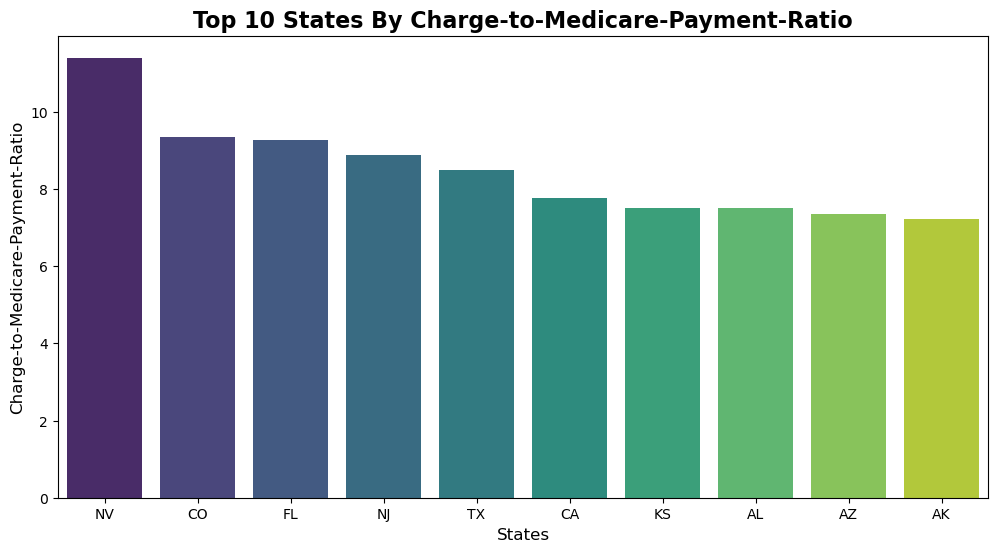

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (12, 6))

sns.barplot(
    data = ratio_by_state.head(10),
    x = 'rndrng_prvdr_state_abrvtn',
    y = 'charge_to_medicare_payment_ratio',
    palette = 'viridis')

plt.title('Top 10 States By Charge-to-Medicare-Payment-Ratio', fontsize = 16, fontweight = 'bold')
plt.xlabel('States', fontsize = 12)
plt.ylabel('Charge-to-Medicare-Payment-Ratio', fontsize = 12)

plt.show()


C:\Users\gurba\AppData\Local\Temp\ipykernel_33152\820896876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


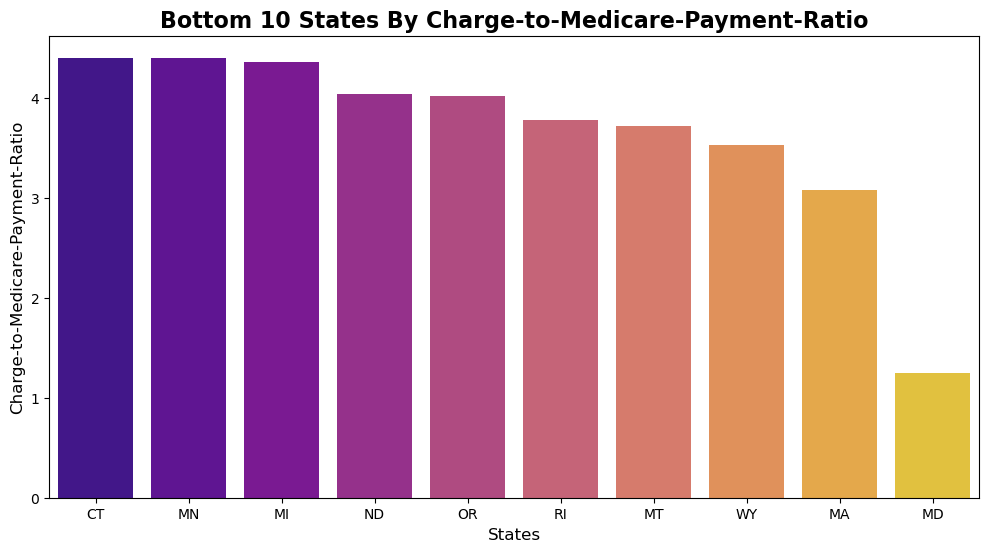

In [66]:
plt.figure(figsize = (12, 6))

sns.barplot(
    data = ratio_by_state.tail(10),
    x = 'rndrng_prvdr_state_abrvtn',
    y = 'charge_to_medicare_payment_ratio',
    palette = 'plasma')

plt.title('Bottom 10 States By Charge-to-Medicare-Payment-Ratio', fontsize = 16, fontweight = 'bold')
plt.xlabel('States', fontsize = 12)
plt.ylabel('Charge-to-Medicare-Payment-Ratio', fontsize = 12)

plt.show()


In [92]:
meaningful_volume_drg.head(10)

,,charge_to_medicare_payment_ratio,tot_dschrgs
drg_cd,drg_desc,,
652,KIDNEY TRANSPLANT,13.991271,6202
651,KIDNEY TRANSPLANT WITH HEMODIALYSIS WITHOUT MCC,11.042153,487
087,TRAUMATIC STUPOR AND COMA <1 HOUR WITHOUT CC/MCC,10.334008,1091
650,KIDNEY TRANSPLANT WITH HEMODIALYSIS WITH MCC,10.132530,2130
440,DISORDERS OF PANCREAS EXCEPT MALIGNANCY WITHOUT CC/MCC,9.880385,263
068,PRECEREBRAL OCCLUSION WITHOUT INFARCTION WITHOUT MCC,9.571110,549
282,"ACUTE MYOCARDIAL INFARCTION, DISCHARGED ALIVE WITHOUT CC/MCC",9.561404,5809
419,LAPAROSCOPIC CHOLECYSTECTOMY WITHOUT C.D.E. WITHOUT CC/MCC,9.465131,2460
066,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION WITHOUT CC/MCC,9.329680,9902


C:\Users\gurba\AppData\Local\Temp\ipykernel_33152\4113561749.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


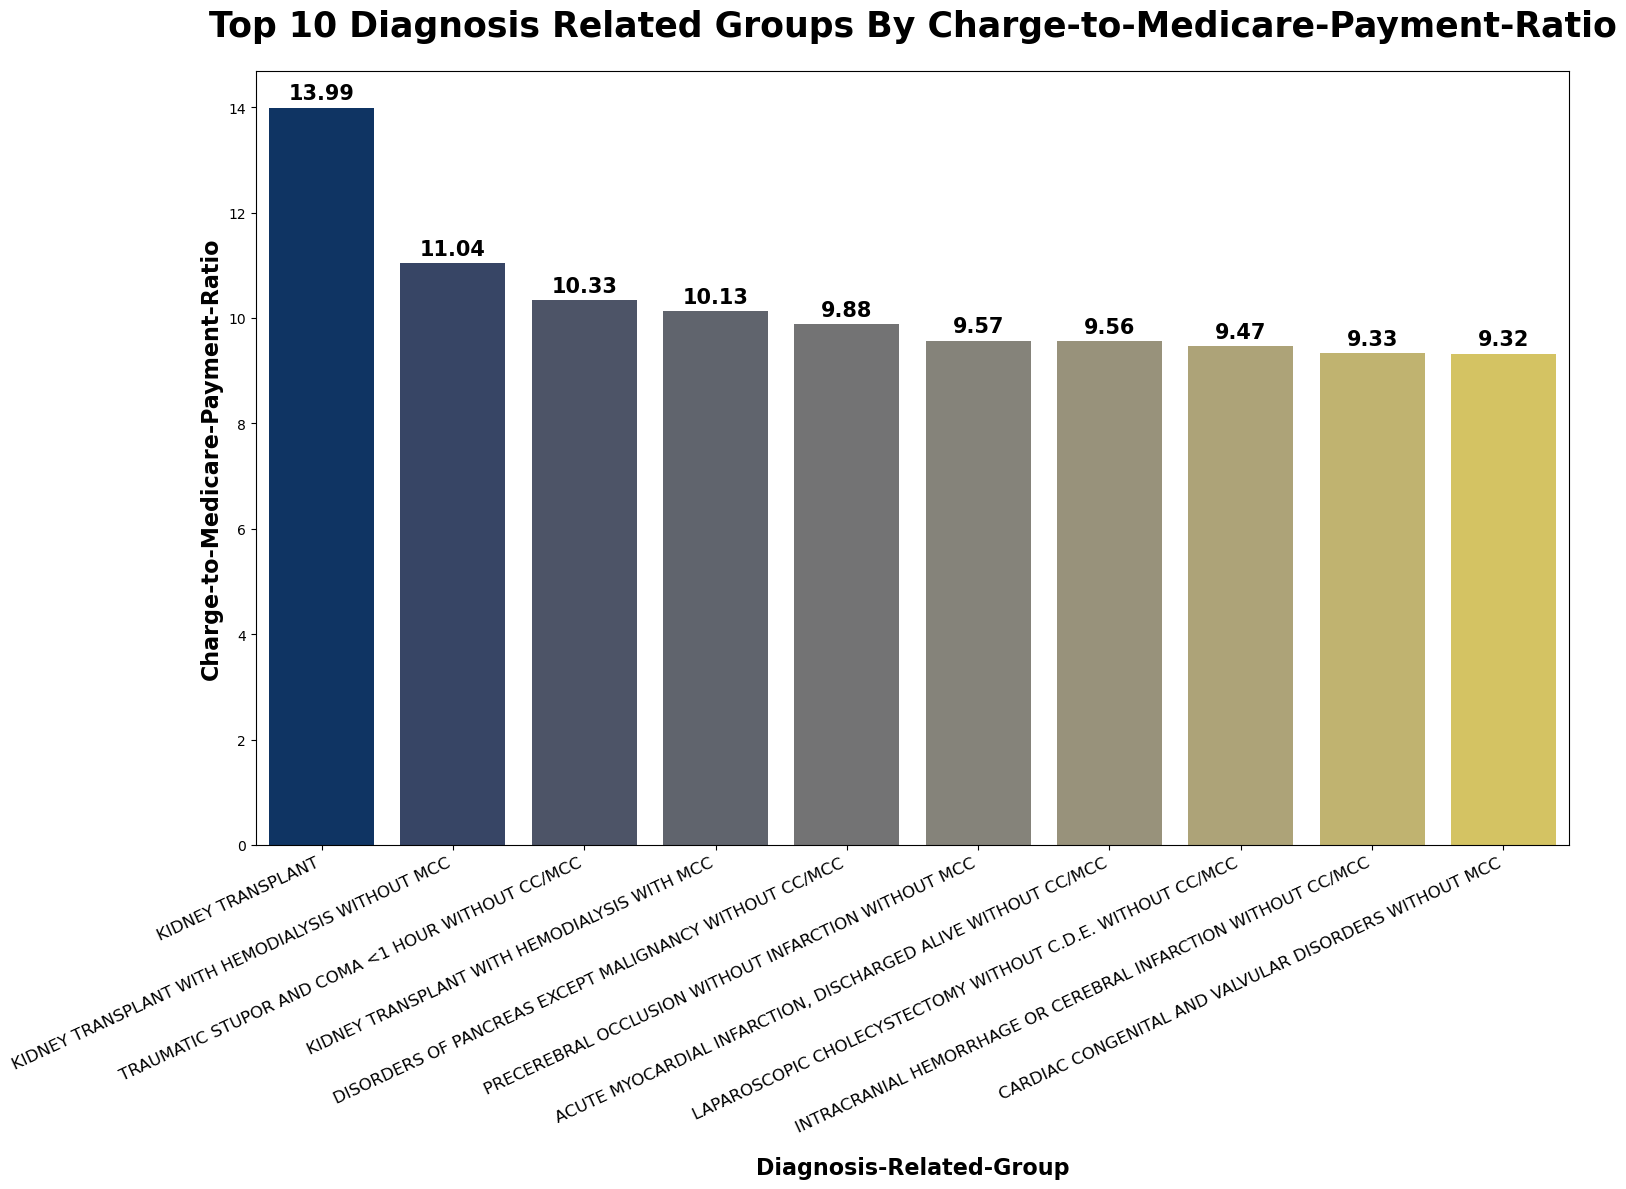

In [96]:
plt.figure(figsize = (16, 12))

ax = sns.barplot(
    data = meaningful_volume_drg.head(10),
    x = 'drg_desc',
    y = 'charge_to_medicare_payment_ratio',
    palette = 'cividis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=15, fontweight='bold')

plt.title('Top 10 Diagnosis Related Groups By Charge-to-Medicare-Payment-Ratio', fontsize = 25, fontweight = 'bold', pad = 25)
plt.xlabel('Diagnosis-Related-Group', fontsize = 16, fontweight = 'bold', labelpad = 15)
plt.ylabel('Charge-to-Medicare-Payment-Ratio', fontsize = 16, fontweight = 'bold')

plt.xticks(rotation = 25, ha = 'right', fontsize = 12)
plt.tight_layout()

plt.show()
